# Introduction to Python in Chemistry Lesson 7

It is much easier to import the data directly, rather than googling or looking it up in a book. 

In chemistry we use physical properties such as boiling points and melting points, and solubility, as these can say wether something might be a good drug for example.. 

there is a lot of data on the internet, and some of it is nicely organised in to tables. 

1. Make a folder called `data` in the same folder where this `ipynb` file is saved.
2. Save the file `chem_mp_bp_dataset.csv` in this folder
3. Open the file `chem_mp_bp_dataset.csv` with a text editor and have a look

In the text editor you will see that it contains many lines of data, with lots of different compounds and their melting points and boiling points. 

4. Open the file with MS Excel

In the spreadsheet you can see the same data, only organised in to columns and rows. We can use Python to organise it the same way. 

5. Close both the text editor and MS Excel

Please first run the import cells below, this gives us the useful software packages we need. 

In [54]:
# 1
import matplotlib.pyplot as plt
import pandas as pd

We are going to learn to read in some data from a separate file. this file is called `chem_mp_bp_dataset.csv`.`csv` stands for 'Comma Separated Values'. 

We are using the pandas library with the nickname `pd`, which we define when we `import` `as` above. 

The file name is entered as a string giving the path to the file. This will save all the data in a `DataFrame`, which will make manipulating the data more easy. 

In [56]:
# 2
df = pd.read_csv('./data/chem_mp_bp_dataset.csv')

In [57]:
df.info() # shows us some information about the data frame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1131 entries, 0 to 1130
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   canonical_smiles  1131 non-null   object 
 1   compLabel         1131 non-null   object 
 2   formula           1131 non-null   object 
 3   bp                1131 non-null   float64
 4   bpUnitLabel       1131 non-null   object 
 5   mp                1131 non-null   float64
 6   mpUnitLabel       1131 non-null   object 
dtypes: float64(2), object(5)
memory usage: 62.0+ KB


Now we need to reindex the dataframe to make it easier to look up molecules. We set the index to be the SMILES string, here labeled as `canonical_smiles`, canonical just meaning there is one smiles per compound.

In [58]:
# remove unnamed 
df = df.set_index('canonical_smiles')

In [59]:
df.head() # shows us the top 5 rows of the dataframe.

,compLabel,formula,bp,bpUnitLabel,mp,mpUnitLabel
canonical_smiles,,,,,,
[H],hydrogen,H₂,-253.0,degree Celsius,-259.0,degree Celsius
[Kr],krypton,Kr,-153.4,degree Celsius,-153.4,degree Celsius
[Rn],radon,Rn,-61.8,degree Celsius,-71.0,degree Celsius
[He],helium,He,-268.9,degree Celsius,-272.2,degree Celsius
[C-]#[O+],carbon monoxide,CO,-191.7,degree Celsius,-205.0,degree Celsius


We can look up different compounds using their smiles strings now. For example, the entry for Helium is in the top row. 

In [60]:
df.loc['[He]']

compLabel              helium
formula                    He
bp                     -268.9
bpUnitLabel    degree Celsius
mp                     -272.2
mpUnitLabel    degree Celsius
Name: [He], dtype: object

To find its boiling point, we use the key `"bp"`

In [61]:
df.loc['[He]']['bp']

-268.9

We can find the boiling points of all the Noble gases and plot them. We should also look up and use the formula to label each of the points.

The code should:

initialise lists to store the data

In a `for` loop: 
1. look up the boiling point and formula
2. add the boiling point to a list
3. add the formula to a list

then plot the boiling points from the list

and label the entries with the formula

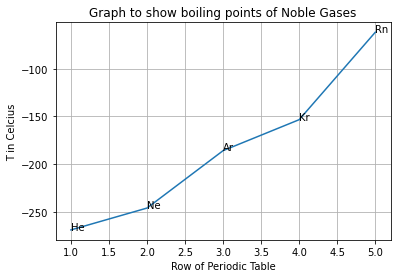

In [52]:
# Smiles strings for the noble gases
nobles = ['[He]', '[Ne]', '[Ar]', '[Kr]', '[Rn]']
row_number = [1,2,3,4,5] # row of the periodic table

# initialises lists to save the data we find
nobles_bpts=[]
nobles_mpts=[]
nobles_formula=[]

# loops though the smiles strings
for smiles in nobles:
    # looks up each bpt and formula
    bpt = df.loc[smiles]['bp']
    formula = df.loc[smiles]['formula']
    # appends them each to a list
    nobles_bpts.append(bpt)
    nobles_formula.append(formula)

# plots bpts vs row numbers
plt.plot(row_number, nobles_bpts)

# annotates each point with the formula
for i, form in enumerate(nobles_formula):
    plt.annotate(form, (row_number[i], nobles_bpts[i]))

# labels and title
plt.xlabel('Row of Periodic Table')
plt.ylabel('T in Celcius')
plt.title('Graph to show boiling points of Noble Gases')
plt.grid();

To find the boiling point for Methane, we just need to use it's SMILES string

To Do:

1. Show the entry for methane, using its SMILES string
2. Show how you get just the boiling point of methane

In [8]:
# 1. 
df.loc['C']


compLabel             methane
formula                   CH₄
bp                    -161.48
bpUnitLabel    degree Celsius
mp                    -182.49
mpUnitLabel    degree Celsius
Name: C, dtype: object

In [9]:
# 2.
df.loc['C']['bp']

-161.48

To do:

- Complete the code below to plot the boiling points of the first 10 alkanes

The code below first:

initialises lists to save the data

In a for loop: 
1. works out the SMILES string
2. look up the boiling point
3. add the boiling point to a list

then plots the entries from that list



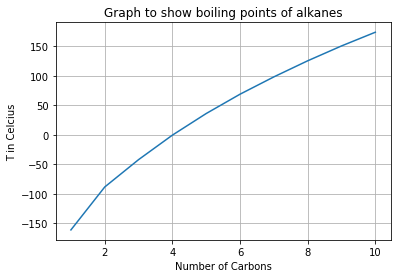

In [46]:
n_carbons = [1,2,3,4,5,6,7,8,9,10]

# initialise lists to save the data we find
alkane_bpts=[]
alkane_formula=[]

# loops though the carbon numbers
for i in n_carbons:
    # works out smiles string
    smiles = 'C'*i
    # looks up each bpt 
    bpt = df.loc[smiles]['bp']
    # appends it to a list
    alkane_bpts.append(bpt)


plt.plot(n_carbons, alkane_bpts)
plt.xlabel('Number of Carbons')
plt.ylabel('T in Celcius')
plt.title('Graph to show boiling points of alkanes')
plt.grid();


To look up the melting point of a compound you need the smiles string and the key `"mp"`.

To do:

- look up the melting point of ethane

In [50]:
# your code here
df.loc['CC']['mp']

-182.8

You can add the melting points to the same graph with some minor adjustments.

To do:

- Complete the code below to plot both melting points and boiling points

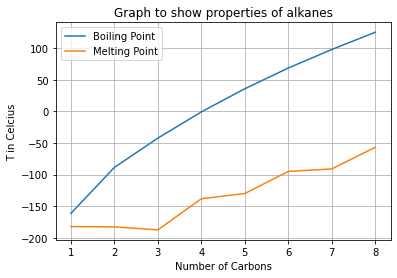

In [53]:
n_carbons = [1,2,3,4,5,6,7,8]

# initialise lists to save the data we find
alkane_bpts=[]
alkane_mpts=[]
alkane_formula=[]

# loops though the carbon numbers
for i in n_carbons:
    # works out smiles string
    smiles = 'C'*i
    # looks up each bpt 
    bpt = df.loc[smiles]['bp']
    # looks up each mpt 
    mpt = df.loc[smiles]['mp']
    # appends them each to a list
    alkane_bpts.append(bpt)
    alkane_mpts.append(mpt)

plt.plot(n_carbons, alkane_bpts, label='Boiling Point')
# need to plot mpt list
# your code here
plt.plot(n_carbons, alkane_mpts, label='Melting Point')
plt.xlabel('Number of Carbons')
plt.ylabel('T in Celcius')
plt.title('Graph to show properties of alkanes')
plt.grid()
plt.legend();

The boiling points form a neat curve, however the melting points ar emuch less regular, this is due to packing effects, as the propane molecule can't pack as tightly as ethane or methane (see the paper [Thallandi and Boese, N. J. Chem, 2000, 24, 579-581](https://pubs.rsc.org/en/content/articlelanding/2000/nj/b004283h), a copy is in the GitHub repository), and preseumably higher odd numbers also find packing more awkward than even numbers. I don't think that anyone is clear on this at the moment though.

This is well beyond any GCSE or A level syllabus, and I don't remember covering it at degree either, so don't worry about it.

Extension:

- Plot the same type of graph for the first 10 straight chain alcohols
- Ensure axes are correctly labelled and the graph has a title
- Plot the same graph but with both alcohols and alkanes on the same graph
- What difficulties might you have with other homologous serieses? try and see. 


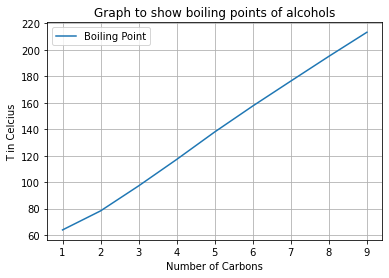

In [16]:
alcohol_bpts=[]
n_carbons = np.arange(1,10)
for i in range(1,10):
    smiles = 'C'*i+'O' # this bit can be tricky
    bpt = df.loc[smiles]['bp']
    alcohol_bpts.append(bpt)

plt.plot(n_carbons, alcohol_bpts, label='Boiling Point')
plt.xlabel('Number of Carbons')
plt.ylabel('T in Celcius')
plt.title('Graph to show boiling points of alcohols')
plt.grid()
plt.legend();

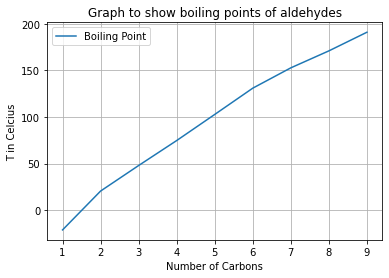

In [17]:
aldehyde_bpts=[]
n_carbons = np.arange(1,10)
for i in range(1,10):
    smiles = 'C'*i+'=O' # this bit can be tricky
    bpt = df.loc[smiles]['bp']
    aldehyde_bpts.append(bpt)

plt.plot(n_carbons, aldehyde_bpts, label='Boiling Point')
plt.xlabel('Number of Carbons')
plt.ylabel('T in Celcius')
plt.title('Graph to show boiling points of aldehydes')
plt.grid()
plt.legend();

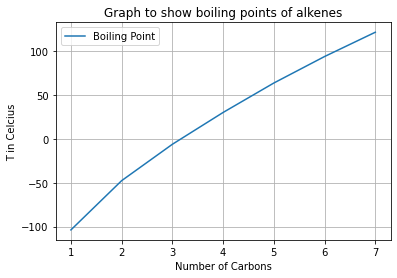

In [26]:
# this one is very difficult as not all alkenes are here, and 
# they are not consistent with which side the C= is on
alkene_bpts=[]
n_carbons = np.arange(1,10)
for i in range(1,10):
    
    try:
        smiles = 'C='+'C'*i # this bit can be tricky
        bpt = df.loc[smiles]['bp']
    except:
        try:
            smiles = 'C'*i+'=C' # this bit can be tricky
            bpt = df.loc[smiles]['bp']
        except:
            break
    
    alkene_bpts.append(bpt)

plt.plot(n_carbons[:len(alkene_bpts)], alkene_bpts, label='Boiling Point')
plt.xlabel('Number of Carbons')
plt.ylabel('T in Celcius')
plt.title('Graph to show boiling points of alkenes')
plt.grid()
plt.legend();

1. Predict the pattern in boiling point for the first four group 4 hydrides, $CH_4$, $SiH_4$, $GeH_4$, $SnH_4$

Your answer here:


should increase from row 1 to row 4, as an extra shell of electrons is tehre each time, so the attractions will be stronger eahc time you go down the group.

You can look up these boiling points using the same dataset, you just need the SMILES strings. 

2. use the dataset to look up the boiling points of the group 4 hydrides for the first 4 rows of the periodic table.

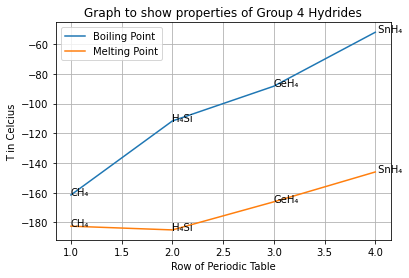

In [13]:
# 5
grp4 = ['C', '[SiH4]','[GeH4]', '[SnH4]']
row_number=np.arange(1,5)
# these are the smiles strings for the group 4 hydrides

# initialises lists to save the data we find
grp4_bpts=[]
grp4_mpts=[] # not in student version
grp4_formula=[]

for smiles in grp4:
    bpt = df.loc[smiles]['bp']
    formula = df.loc[smiles]['formula']
    mpt = df.loc[smiles]['mp']
    grp4_bpts.append(bpt)
    grp4_mpts.append(mpt)# not in student version
    grp4_formula.append(formula)

plt.plot(row_number, grp4_bpts, label='Boiling Point')
plt.plot(row_number, grp4_mpts, label='Melting Point')# not in student version

for i, form in enumerate(grp4_formula):
    # annotate with the formula
    plt.annotate(form, (row_number[i], grp4_bpts[i]))
    plt.annotate(form, (row_number[i], grp4_mpts[i])) # not in student version
plt.xlabel('Row of Periodic Table')
plt.ylabel('T in Celcius')
plt.title('Graph to show properties of Group 4 Hydrides')
plt.grid()
plt.legend();

I have no idea why these show a drop in mpt between $CH_4$ and $SiH_4$. 

Will stick to bpt in student version. 

1. Predict the trend in other groups, for example groups 5 and 6. 
2. Will the boiling points in group 5 be higher or lower than the corresponding Group 4 Hydrides?
3. Explain your reasoning

Answers below:
1. trend should be the same, increasing numbers of electrons mean higher boiling points as you go down the group.
2. Group 5 should be higher than 4, group 6 should be higher than group 5, as they are slightly bigger.. 
3. Group 5 will have slightly more electrons than group 
numbers of hydrogens don't change numbers of electrons.. but is this right? I am not sure.. Pretty sure the molecular weight argument will come up, which I don't think should have anything to do with it. 


In [105]:
#7
# these are the smiles strings for the group 5 and 6 hydrides
grp5 = ['N', 'P','[AsH3]', '[SbH3]']
grp6 = ['O', 'S', '[SeH2]','[TeH2]']


TODO: 
- plot a graph with the boiling points for hydrides in group 4, 5 and 6
- the smiles strings are above
- make sure you have fully labelled your graph
- What do you learn from this graph. 
- If you finish.. how efficient is your code? is there a better way to do this?

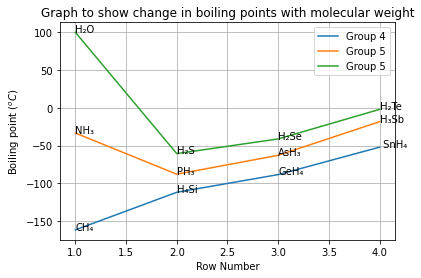

In [124]:
# 8

row_number=[1,2,3,4]

# group 4 hydrides
# initialises lists to save the data we find
grp4_bpts=[]
grp4_formula=[]

for smiles in grp4:
    bpt = df.loc[smiles]['bp']
    formula = df.loc[smiles]['formula']
    mpt = df.loc[smiles]['mp']
    grp4_bpts.append(bpt)
    grp4_formula.append(formula)

# group 5 hydrides
# initialises lists to save the data we find
grp5_bpts=[]
grp5_formula=[]

for smiles in grp5:
    bpt = df.loc[smiles]['bp']
    formula = df.loc[smiles]['formula']
    mpt = df.loc[smiles]['mp']
    grp5_bpts.append(bpt)
    grp5_formula.append(formula)

# group 6 hydrides
# initialises lists to save the data we find
grp6_bpts=[]
grp6_formula=[]

for smiles in grp6:
    bpt = df.loc[smiles]['bp']
    formula = df.loc[smiles]['formula']
    mpt = df.loc[smiles]['mp']
    grp6_bpts.append(bpt)
    grp6_formula.append(formula)


# this plots the points, and makes the labels for the line
plt.plot(row_number, grp4_bpts, label='Group 4')
plt.plot(row_number, grp5_bpts, label='Group 5')
plt.plot(row_number, grp6_bpts, label='Group 5')

for i in range(4):
    plt.annotate(grp4_formula[i], (row[i], grp4_bpts[i]))
    plt.annotate(grp5_formula[i], (row[i], grp5_bpts[i]))
    plt.annotate(grp6_formula[i], (row[i], grp6_bpts[i]))

#label axes and make a title
plt.legend()
plt.title('Graph to show change in boiling points with molecular weight')
plt.xlabel('Row Number')
plt.ylabel('Boiling point ($^oC$)')
plt.grid();

Is your code efficient and could it be written better?
Your answer here:

My code is moderately efficient because I don't iterate though the dataframe more than once, it uses the index instead.

However I have written out three bits of code that are the same and should probably go in a for loop, like below:

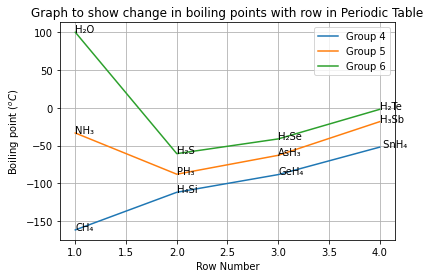

In [129]:
# initialise list of smiles lists
sm_lists=[grp4, grp5, grp6]

# initialises empty lists to save the data we find
bp_lsts=[]
form_lsts=[]

# append an empty list for each of the set of smiles strings
for lst in sm_lists: 
    bp_lsts.append([])
    form_lsts.append([])

# get data
for i in range(3): # there are 3 lists
    for j in range(4): # there are 4 compounds in each list
        smiles = sm_lists[i][j]
        bpt = df.loc[smiles]['bp']
        formula = df.loc[smiles]['formula']
        # print(smiles, bpt, formula)
        bp_lsts[i].append(bpt)
        form_lsts[i].append(formula)

# plot data
for i in range(3): # there are 3 lists
    # i+4 is group number
    # plot the graph
    plt.plot(row_number, bp_lsts[i], label=f'Group {i+4}')
    # annotate the graph
    for j in range(4): # 4 compounds in each
        # j is the number row of the PT
        # annotate each point
        plt.annotate(form_lsts[i][j], (row_number[j], bp_lsts[i][j]))


#label axes and make a title
plt.legend()
plt.title('Graph to show change in boiling points with row in Periodic Table')
plt.xlabel('Row Number')
plt.ylabel('Boiling point ($^oC$)')
plt.grid();

The above was a bit fiddly for me, would be quite difficult I think for them..